# DSCI 552 — Homework 2
## Linear and KNN Regression on the Combined Cycle Power Plant Data Set

**Name:** Yanchen Liu

Response: net hourly electrical energy output **PE** (MW). Predictors: ambient temperature **AT** ($^\circ$C), exhaust vacuum **V** (cm Hg), ambient pressure **AP** (mbar) and relative humidity **RH** (%).

In [1]:
import os
import urllib.request
import zipfile
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.precision", 4)

# Blue / orange: colour-blind safe pair (same as HW1)
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.6,
    "lines.linewidth": 2,
})

## 1(a) Download the data

The UCI zip contains `CCPP/Folds5x2_pp.xlsx`. The workbook has five sheets, each a different shuffle of the same 9568 rows; as instructed we use **Sheet1**. The cell downloads the zip only if the file is not already in `../data`.

In [2]:
DATA_DIR = "../data/Homework 2 Data"
URL = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"
XLSX_PATH = os.path.join(DATA_DIR, "CCPP", "Folds5x2_pp.xlsx")

if not os.path.exists(XLSX_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path, _ = urllib.request.urlretrieve(URL, os.path.join(DATA_DIR, "ccpp.zip"))
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)

df = pd.read_excel(XLSX_PATH, sheet_name="Sheet1")
PREDICTORS = ["AT", "V", "AP", "RH"]
RESPONSE = "PE"
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) Exploring the data

### 1(b)i. Rows and columns

In [3]:
n_rows, n_cols = df.shape
print(f"rows = {n_rows}, columns = {n_cols}")
print(f"missing values = {df.isna().sum().sum()}, fully duplicated rows = {df.duplicated().sum()}")

rows = 9568, columns = 5
missing values = 0, fully duplicated rows = 41


There are **9568 rows** and **5 columns**.

- Each **row** is one hour of operation of the power plant at full load (hourly averages collected over 2006–2011).
- The **columns** are the four ambient variables used as predictors — temperature (AT), exhaust vacuum (V), ambient pressure (AP), relative humidity (RH) — and the response, net hourly electrical energy output (PE).

There are no missing values. 41 rows are exact duplicates of another row; with hourly readings rounded to two decimals this is plausible, so we keep them.

### 1(b)ii. Pairwise scatterplots

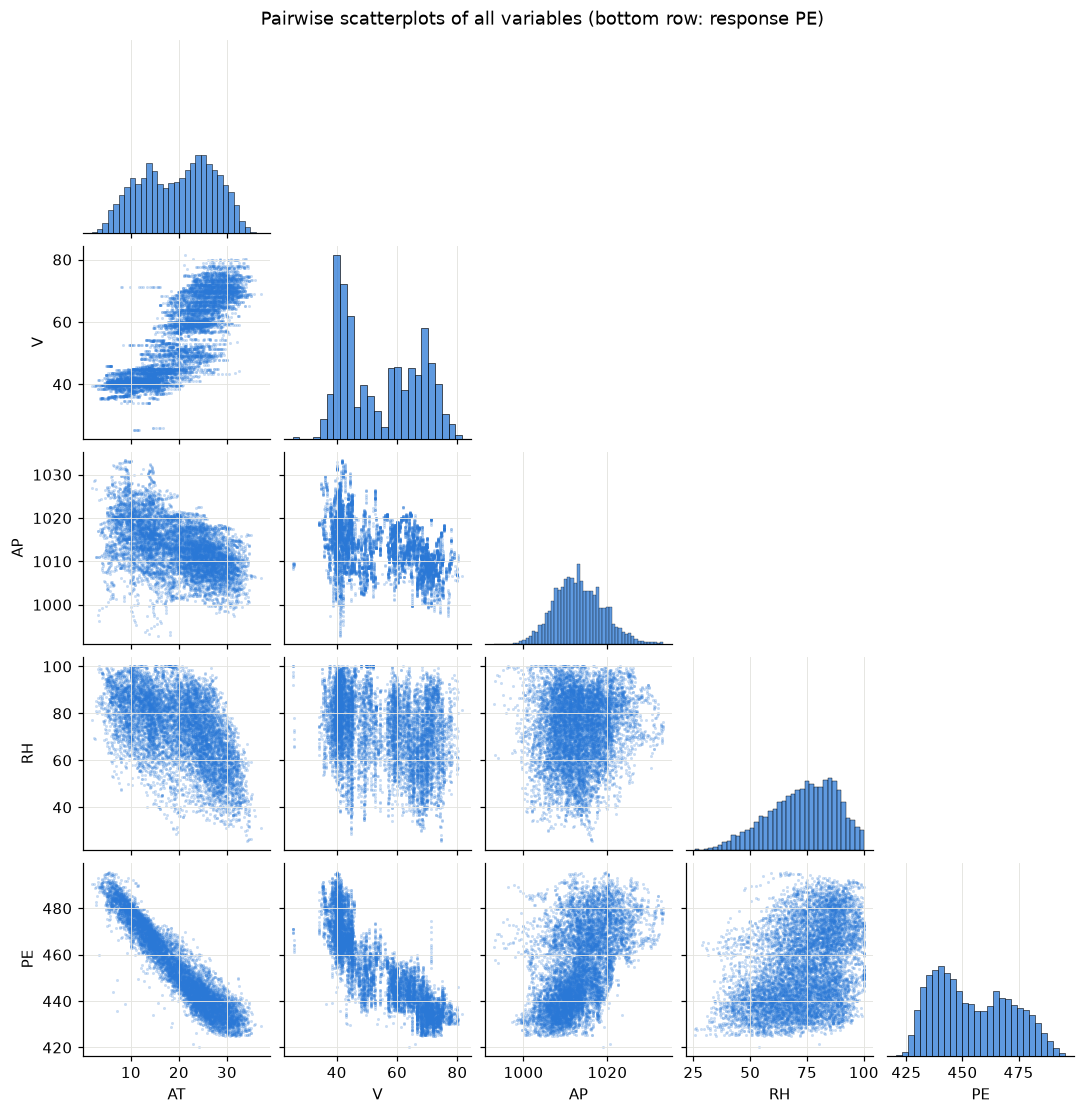

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [4]:
g = sns.pairplot(
    df,
    vars=PREDICTORS + [RESPONSE],
    plot_kws={"s": 4, "alpha": 0.25, "linewidth": 0, "color": BLUE},
    diag_kws={"color": BLUE},
    height=2.0,
    corner=True,
)
g.figure.suptitle("Pairwise scatterplots of all variables (bottom row: response PE)", y=1.01)
plt.show()

df.corr().round(3)

Findings:

- **AT vs. PE** is a strong, almost linear, negative relationship (correlation $-0.95$): hotter air is less dense, so the gas turbine produces less power. The cloud bends slightly at the ends, a hint of mild nonlinearity.
- **V vs. PE** is also strongly negative ($r = -0.87$), but noisier and with visible vertical bands. The bands come from V taking a limited set of values (the vacuum is set by operating conditions).
- **AP vs. PE** ($r = 0.52$) and **RH vs. PE** ($r = 0.39$) are weakly positive, with a lot of scatter.
- The predictors are correlated with each other. **AT and V** are strongly positively correlated ($r = 0.84$), and AT is moderately negatively correlated with AP ($-0.51$) and RH ($-0.54$). This collinearity matters when we compare simple and multiple regression in 1(e).
- There are no gross errors in the data. RH is capped near 100% and AP is concentrated around 1013 mbar (standard sea-level pressure).

### 1(b)iii. Summary statistics

In [5]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary.round(2)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


For every variable the mean and the median are close, so no distribution is strongly skewed. AT and RH are slightly left-skewed (median > mean), while V and PE are slightly right-skewed (mean > median). AP has by far the smallest relative spread (IQR 8.2 mbar around 1013), which is why its regression coefficient per unit is large but its explanatory power is small.

## 1(c) Simple linear regression for each predictor

For each predictor $X$ we fit $\mathrm{PE} = \beta_0 + \beta_1 X + \epsilon$ with `statsmodels` OLS and test $H_0: \beta_1 = 0$.

In [6]:
simple = {p: smf.ols(f"{RESPONSE} ~ {p}", data=df).fit() for p in PREDICTORS}

pd.DataFrame({
    p: {
        "beta_0": m.params["Intercept"],
        "beta_1": m.params[p],
        "SE(beta_1)": m.bse[p],
        "t": m.tvalues[p],
        "p-value": m.pvalues[p],
        "R^2": m.rsquared,
        "RSE": np.sqrt(m.scale),
    }
    for p, m in simple.items()
}).T

,beta_0,beta_1,SE(beta_1),t,p-value,R^2,RSE
AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,5.4257
V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,8.4220
AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,14.5951
RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,15.7179


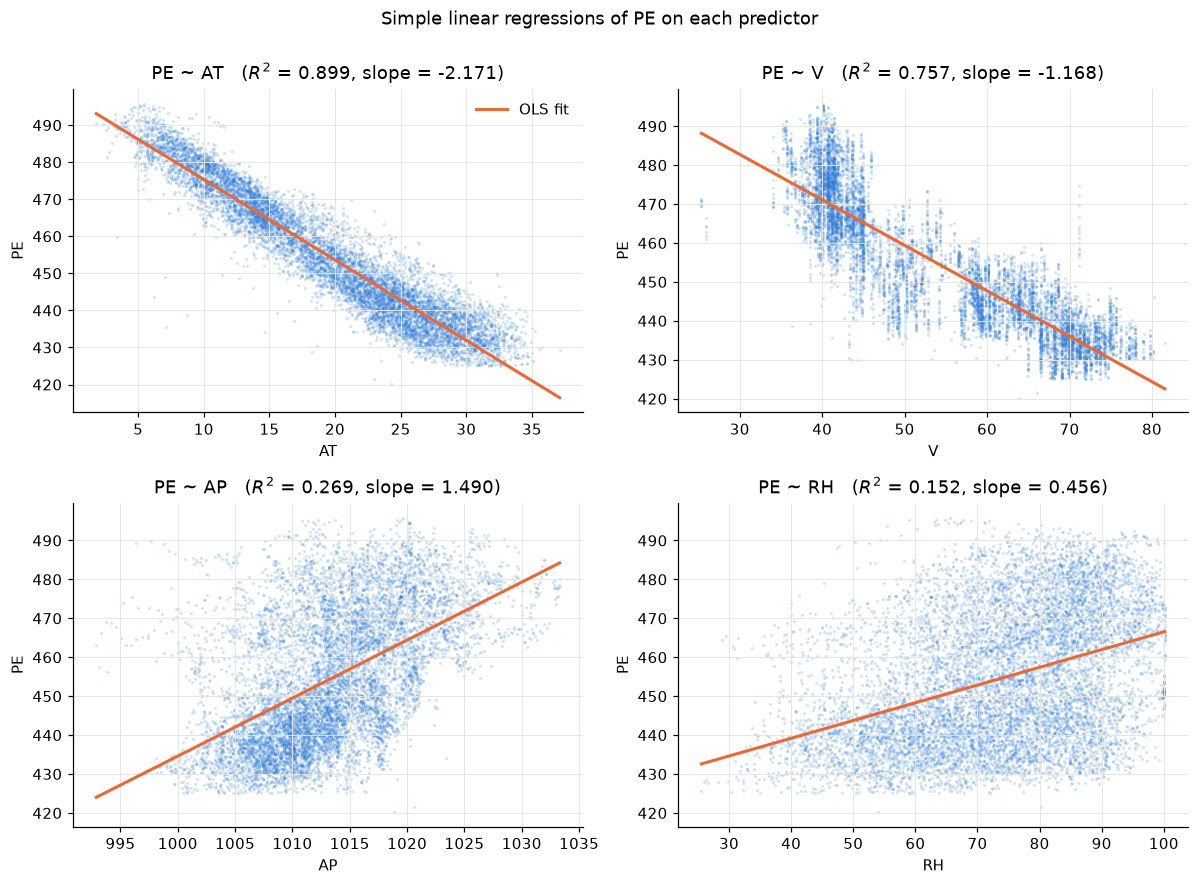

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), PREDICTORS):
    m = simple[p]
    ax.scatter(df[p], df[RESPONSE], s=4, alpha=0.2, color=BLUE, linewidths=0)
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(xs, m.params["Intercept"] + m.params[p] * xs, color=ORANGE, label="OLS fit")
    ax.set_title(f"PE ~ {p}   ($R^2$ = {m.rsquared:.3f}, slope = {m.params[p]:.3f})")
    ax.set_xlabel(p)
    ax.set_ylabel("PE")
axes[0, 0].legend(frameon=False)
fig.suptitle("Simple linear regressions of PE on each predictor", y=1.0)
fig.tight_layout()
plt.show()

**Results.** All four slopes are statistically significant: every p-value is numerically 0 (the $t$-statistics range from 41 for RH to 290 for AT). With $n = 9568$ even small effects are detected, so the more informative numbers are the effect sizes and $R^2$:

| Predictor | Slope | $R^2$ | Interpretation |
|---|---|---|---|
| AT | $-2.17$ | 0.899 | each extra $^\circ$C costs about 2.2 MW; AT alone explains 90% of the variance |
| V | $-1.17$ | 0.757 | strong negative association |
| AP | $+1.49$ | 0.269 | weak positive association |
| RH | $+0.46$ | 0.152 | weak positive association |

The plots back this up: the AT and V fits follow the data closely, while for AP and RH the line captures only a trend inside a wide band of scatter.

**Outliers.** Below we look at three diagnostics for each simple regression: externally studentized residuals ($|r_i| > 3$ flags a response outlier), leverage ($h_i > 3\bar h = 6/n$ flags an unusual $x$ value), and Cook's distance (influence of each point on the fit). We then refit without the $|r_i| > 3$ points to see whether they matter.

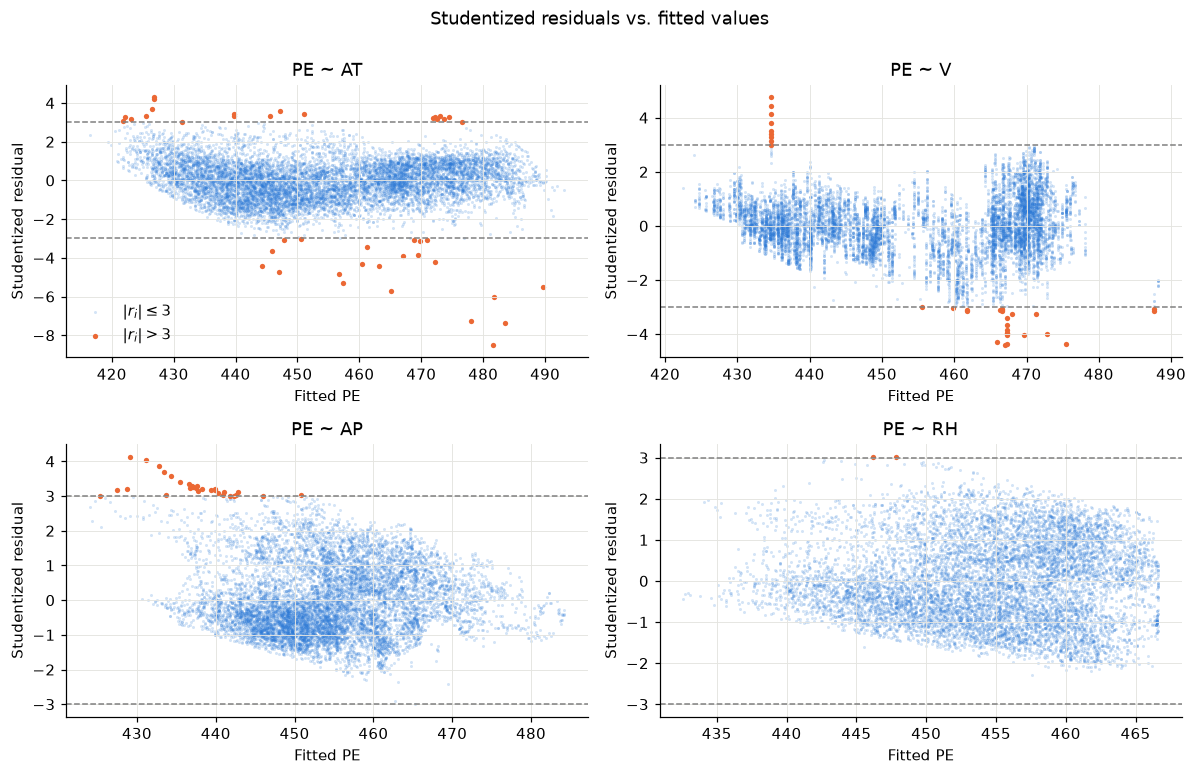

,|stud. resid| > 3,high leverage (h > 6/n),max Cook's D,slope (all data),slope (outliers removed),R^2 (outliers removed)
AT,42.0,7.0,0.0143,-2.1713,-2.1802,0.9064
V,33.0,13.0,0.0032,-1.1681,-1.1769,0.7670
AP,30.0,239.0,0.0082,1.4899,1.5401,0.2864
RH,2.0,173.0,0.0021,0.4557,0.4564,0.1526


In [8]:
rows = {}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, p in zip(axes.ravel(), PREDICTORS):
    m = simple[p]
    infl = m.get_influence()
    r = infl.resid_studentized_external
    lev = infl.hat_matrix_diag
    cooks = infl.cooks_distance[0]
    refit = smf.ols(f"{RESPONSE} ~ {p}", data=df[np.abs(r) <= 3]).fit()
    rows[p] = {
        "|stud. resid| > 3": int((np.abs(r) > 3).sum()),
        "high leverage (h > 6/n)": int((lev > 6 / len(df)).sum()),
        "max Cook's D": cooks.max(),
        "slope (all data)": m.params[p],
        "slope (outliers removed)": refit.params[p],
        "R^2 (outliers removed)": refit.rsquared,
    }
    out = np.abs(r) > 3
    ax.scatter(m.fittedvalues[~out], r[~out], s=4, alpha=0.2, color=BLUE, linewidths=0, label="$|r_i| \\leq 3$")
    ax.scatter(m.fittedvalues[out], r[out], s=12, color=ORANGE, linewidths=0, label="$|r_i| > 3$")
    ax.axhline(3, color="grey", ls="--", lw=1)
    ax.axhline(-3, color="grey", ls="--", lw=1)
    ax.set_title(f"PE ~ {p}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Studentized residual")
axes[0, 0].legend(frameon=False, loc="lower left")
fig.suptitle("Studentized residuals vs. fitted values", y=1.0)
fig.tight_layout()
plt.show()

pd.DataFrame(rows).T

- A few dozen points per model have $|r_i| > 3$ (about 0.3–0.4% of the data, close to what heavier-than-normal tails would produce). For AT the most extreme ones (studentized residuals down to about $-8$) are hours with unusually **low** output for the temperature.
- No point is influential: the largest Cook's distance is 0.014, far below the usual concern level of 1. High-leverage points for AP and RH are simply the ends of their ranges (very high/low pressure, humidity near 100%), not errors.
- Removing the $|r_i| > 3$ points changes the slopes by less than 4% and $R^2$ by at most 0.02, so conclusions don't change.

We therefore **do not remove any outliers**. They are genuine hourly measurements, not recording errors, and none of them drives the fit. The residual plot for AT also shows curvature (residuals are mostly positive at both ends of the fitted range and negative in the middle), which points toward the nonlinear terms examined in 1(f).

## 1(d) Multiple linear regression

$\mathrm{PE} = \beta_0 + \beta_1\,\mathrm{AT} + \beta_2\,\mathrm{V} + \beta_3\,\mathrm{AP} + \beta_4\,\mathrm{RH} + \epsilon$

In [9]:
multi = smf.ols(f"{RESPONSE} ~ " + " + ".join(PREDICTORS), data=df).fit()
print(multi.summary().tables[0])
print(multi.summary().tables[1])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:08:27   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

- The model explains $R^2 = 0.929$ of the variance, up from 0.899 for AT alone. The residual standard error is about 4.56 MW, and the overall $F$-statistic ($3.1 \times 10^4$) has p-value $\approx 0$.
- Every coefficient has p-value $< 0.001$, so **we can reject $H_0: \beta_j = 0$ for all four predictors (AT, V, AP and RH)**. AT is by far the most important ($t = -129$), followed by RH ($t = -38$), V ($t = -32$) and AP ($t = 6.6$).
- Holding the other variables fixed, one more $^\circ$C of temperature lowers output by about 1.98 MW, one more cm Hg of vacuum by 0.23 MW, and one more % humidity by 0.16 MW; one more mbar of pressure raises it by 0.06 MW.
- The large condition number reflects the raw scale of AP (around 1013) together with the AT–V correlation. It inflates the intercept's standard error but does not affect the significance of the slopes here.

## 1(e) Simple vs. multiple regression coefficients

,simple (1c),multiple (1d)
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


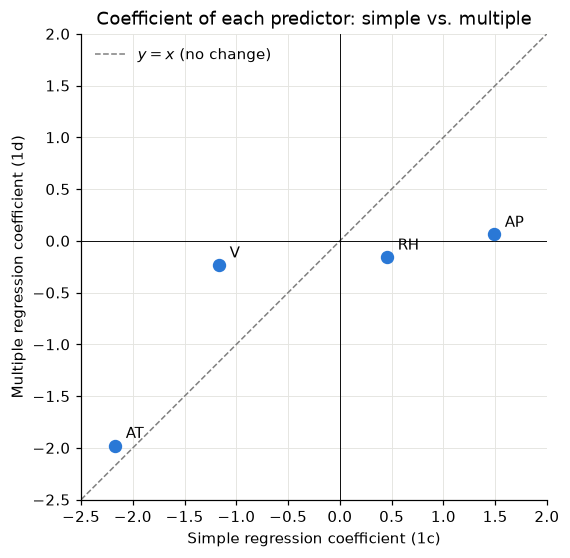

In [10]:
coef = pd.DataFrame({
    "simple (1c)": {p: simple[p].params[p] for p in PREDICTORS},
    "multiple (1d)": multi.params[PREDICTORS],
})
display(coef)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(coef["simple (1c)"], coef["multiple (1d)"], s=60, color=BLUE, zorder=3)
for p, (x, y) in coef.iterrows():
    ax.annotate(p, (x, y), xytext=(7, 5), textcoords="offset points")
lim = [-2.5, 2.0]
ax.plot(lim, lim, color="grey", ls="--", lw=1, label="$y = x$ (no change)")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect("equal")
ax.set_xlabel("Simple regression coefficient (1c)")
ax.set_ylabel("Multiple regression coefficient (1d)")
ax.set_title("Coefficient of each predictor: simple vs. multiple")
ax.legend(frameon=False, loc="upper left")
plt.show()

- **AT** barely changes ($-2.17 \to -1.98$) and stays close to the $y = x$ line: its effect is direct, not borrowed from the other predictors.
- **V** shrinks by a factor of five ($-1.17 \to -0.23$). V is strongly correlated with AT ($r = 0.84$), so in the simple regression V is mostly standing in for temperature. Once AT is in the model, only a small extra effect of V remains.
- **AP** collapses from $+1.49$ to $+0.06$. High pressure tends to come with low temperature ($r = -0.51$), so the simple slope mainly reflects AT again.
- **RH** even **changes sign** ($+0.46 \to -0.16$). Humid hours tend to be cooler ($r = -0.54$), which makes RH look beneficial on its own. At a fixed temperature, higher humidity actually lowers output slightly.

So the simple regressions overstate the effects of V, AP and RH because of their correlation with AT. The multiple regression coefficients are the ones to interpret as "effect of this variable with the others held fixed".

## 1(f) Nonlinear association

For each predictor we fit $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$. We center $X$ at its mean before taking powers. This fits exactly the same cubic curve, but it avoids numerical problems: for AP the raw $X^3$ is about $10^9$ and nearly collinear with $X$. Besides the individual $t$-tests we use an $F$-test of the cubic model against the linear one ($H_0: \beta_2 = \beta_3 = 0$).

In [11]:
rows = {}
cubic = {}
for p in PREDICTORS:
    d = df.assign(x=df[p] - df[p].mean())
    lin = smf.ols(f"{RESPONSE} ~ x", data=d).fit()
    cub = smf.ols(f"{RESPONSE} ~ x + I(x**2) + I(x**3)", data=d).fit()
    cubic[p] = cub
    f_test = sm.stats.anova_lm(lin, cub).iloc[1]
    rows[p] = {
        "p(X)": cub.pvalues["x"],
        "p(X^2)": cub.pvalues["I(x ** 2)"],
        "p(X^3)": cub.pvalues["I(x ** 3)"],
        "R^2 linear": lin.rsquared,
        "R^2 cubic": cub.rsquared,
        "F (cubic vs linear)": f_test["F"],
        "p (F-test)": f_test["Pr(>F)"],
    }
pd.DataFrame(rows).T

,p(X),p(X^2),p(X^3),R^2 linear,R^2 cubic,F (cubic vs linear),p (F-test)
AT,0.0000e+00,3.3118e-231,3.6522e-110,0.8989,0.9119,701.9673,3.4784e-285
V,0.0000e+00,8.9770e-131,1.3735e-02,0.7565,0.7750,393.3141,7.0403e-165
AP,0.0000e+00,2.1927e-46,2.1233e-67,0.2688,0.2975,195.8856,4.2091e-84
RH,9.6487e-152,1.0139e-01,1.4403e-05,0.1519,0.1537,10.1889,3.7996e-05


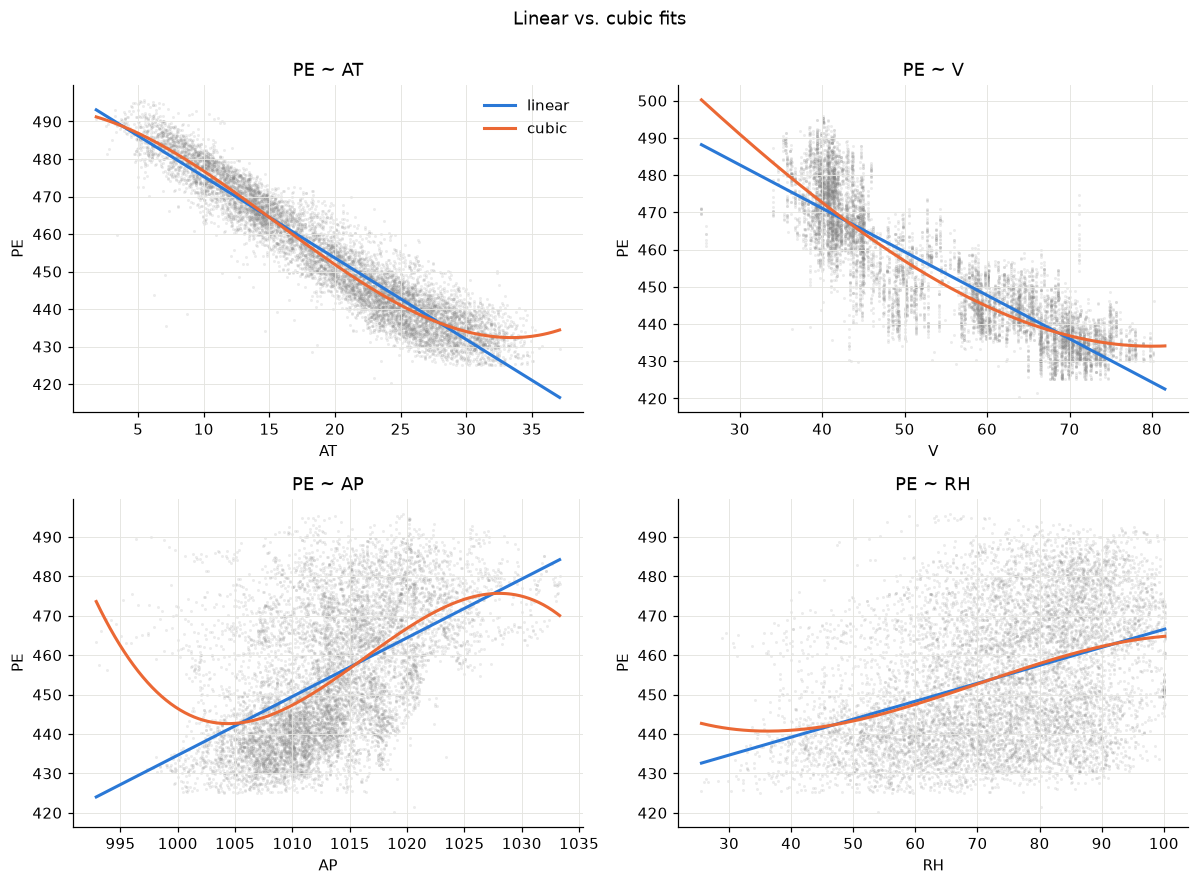

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), PREDICTORS):
    ax.scatter(df[p], df[RESPONSE], s=4, alpha=0.15, color="grey", linewidths=0)
    xs = np.linspace(df[p].min(), df[p].max(), 200)
    grid = pd.DataFrame({"x": xs - df[p].mean()})
    ax.plot(xs, simple[p].params["Intercept"] + simple[p].params[p] * xs, color=BLUE, label="linear")
    ax.plot(xs, cubic[p].predict(grid), color=ORANGE, label="cubic")
    ax.set_title(f"PE ~ {p}")
    ax.set_xlabel(p)
    ax.set_ylabel("PE")
axes[0, 0].legend(frameon=False)
fig.suptitle("Linear vs. cubic fits", y=1.0)
fig.tight_layout()
plt.show()

**Yes, there is evidence of nonlinear association for all four predictors.** For each of them the $F$-test rejects the linear model in favour of the cubic one at any usual level.

- **AT**: $X^2$ and $X^3$ are both highly significant, and $R^2$ rises from 0.899 to 0.912. The cubic follows the flattening of output at low temperatures.
- **V**: $X^2$ is highly significant and $X^3$ is significant at the 5% level ($p \approx 0.014$). $R^2$ rises from 0.757 to 0.775.
- **AP**: $X^2$ and $X^3$ are both highly significant ($R^2$ 0.269 to 0.298). The cubic flattens at high pressure.
- **RH**: this is the weakest case. $X^2$ is **not** significant ($p \approx 0.10$), $X^3$ is ($p \approx 10^{-5}$), and $R^2$ only moves from 0.152 to 0.154. The nonlinearity is statistically detectable because $n$ is large, but it is practically negligible.

The nonlinearity is real but modest: in every case the cubic curve stays close to the straight line over the bulk of the data.

## 1(g) Interactions of predictors

Full model with all four main effects and all six pairwise interactions: `PE ~ (AT + V + AP + RH)**2`.

In [13]:
interact = smf.ols(f"{RESPONSE} ~ ({' + '.join(PREDICTORS)})**2", data=df).fit()
print(f"R^2 = {interact.rsquared:.4f} (additive model: {multi.rsquared:.4f})")
print(interact.summary().tables[1])

anova = sm.stats.anova_lm(multi, interact).iloc[1]
print(f"\nF-test of all 6 interactions jointly: F = {anova['F']:.1f}, p = {anova['Pr(>F)']:.3g}")

R^2 = 0.9363 (additive model: 0.9287)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.000     531.631     839.934
AT            -4.3470      2.373     -1.832      0.067      -8.999       0.305
V             -7.6749      1.351     -5.682      0.000     -10.323      -5.027
AP            -0.1524      0.077     -1.983      0.047      -0.303      -0.002
RH             1.5709      0.773      2.031      0.042       0.055       3.087
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         

**Yes, there is evidence of interaction effects.** Together, the six interactions raise $R^2$ from 0.929 to 0.936 and are jointly highly significant (joint $F$-test). Individually, at the 5% level:

- **Significant:** AT:V ($p \approx 0$, $t = 23$), AT:RH ($p < 10^{-9}$), V:AP ($p < 10^{-6}$) and AP:RH ($p \approx 0.034$).
- **Not significant:** AT:AP ($p \approx 0.45$) and V:RH ($p \approx 0.09$).

The positive AT:V coefficient means that the output lost per extra degree of temperature is smaller when the exhaust vacuum is high. In this model the main effect of AT itself is no longer significant ($p \approx 0.07$). That is expected: with interactions present, the main effect only describes the slope at V = AP = RH = 0, far outside the data. Its p-value does not mean AT is unimportant.

## 1(h) Improving the model

We randomly split the data into 70% training / 30% test (fixed seed for reproducibility). Two models are fitted **on the training set only**:

1. **Linear:** all four predictors, no interactions or powers.
2. **Selected quadratic + interaction model:** start from all main effects, all 6 pairwise interactions and all 4 squared terms (14 terms). Then apply **backward elimination by p-value**: repeatedly drop the least significant term with $p > 0.05$ and refit.

   *Care with interaction terms (hierarchy principle):* a main effect is only a candidate for removal once no interaction or square containing it remains. The reason is that the p-value of a main effect in the presence of its interaction depends on where the other variable is centered, so it is not a meaningful test on its own.

In [14]:
train, test = train_test_split(df, train_size=0.7, random_state=552)
print(f"train = {len(train)} rows, test = {len(test)} rows")


def mse_report(model, name):
    return {
        "model": name,
        "n_terms": len(model.params) - 1,
        "train MSE": mean_squared_error(train[RESPONSE], model.predict(train)),
        "test MSE": mean_squared_error(test[RESPONSE], model.predict(test)),
    }


def parents(term):
    # Main effects that a higher-order term is built from
    if ":" in term:
        return set(term.split(":"))
    if term.startswith("I("):
        return {term[2:].split("**")[0].strip()}
    return set()


def backward_eliminate(terms, data, alpha=0.05, verbose=True):
    terms = list(terms)
    while True:
        model = smf.ols(f"{RESPONSE} ~ " + " + ".join(terms), data=data).fit()
        # Main effects still needed by a remaining higher-order term are protected
        protected = set().union(*(parents(t) for t in terms))
        candidates = {t: model.pvalues[t] for t in terms if t not in protected}
        worst = max(candidates, key=candidates.get)
        if candidates[worst] <= alpha:
            return model
        if verbose:
            print(f"drop {worst:12s} p = {candidates[worst]:.4f}")
        terms.remove(worst)


linear_h = smf.ols(f"{RESPONSE} ~ " + " + ".join(PREDICTORS), data=train).fit()

full_terms = (
    PREDICTORS
    + [f"{a}:{b}" for a, b in combinations(PREDICTORS, 2)]
    + [f"I({p} ** 2)" for p in PREDICTORS]
)
full_h = smf.ols(f"{RESPONSE} ~ " + " + ".join(full_terms), data=train).fit()
selected_h = backward_eliminate(full_terms, train)
print()
print(selected_h.summary().tables[1])

train = 6697 rows, test = 2871 rows
drop AT:AP        p = 0.4923
drop V:RH         p = 0.3791
drop I(V ** 2)    p = 0.0931

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7943.0909   1227.942     -6.469      0.000   -1.04e+04   -5535.932
AT            -2.7285      0.112    -24.291      0.000      -2.949      -2.508
V             -4.6715      1.088     -4.293      0.000      -6.805      -2.538
AP            16.5076      2.388      6.914      0.000      11.827      21.188
RH             4.0672      0.820      4.960      0.000       2.460       5.675
AT:V           0.0083      0.002      5.518      0.000       0.005       0.011
AT:RH         -0.0044      0.001     -4.773      0.000      -0.006      -0.003
V:AP           0.0042      0.001      3.905      0.000       0.002       0.006
AP:RH         -0.0038      0.001     -4.794      0.000      -0.005      -0.002
I(AT **

In [15]:
results_h = pd.DataFrame([
    mse_report(linear_h, "linear (all 4 predictors)"),
    mse_report(full_h, "all interactions + squares (before selection)"),
    mse_report(selected_h, "selected interactions + squares"),
]).set_index("model")
results_h

,n_terms,train MSE,test MSE
model,,,
linear (all 4 predictors),4,20.3547,21.7414
all interactions + squares (before selection),14,17.6979,19.0818
selected interactions + squares,11,17.7087,19.0829


**Backward elimination** removed three terms, one at a time: AT:AP ($p = 0.49$), V:RH ($p = 0.38$) and $\mathrm{V}^2$ ($p = 0.09$). The selected model keeps 11 terms, all significant at $p < 0.001$: the 4 main effects, 4 interactions (AT:V, AT:RH, V:AP, AP:RH) and 3 squares ($\mathrm{AT}^2$, $\mathrm{AP}^2$, $\mathrm{RH}^2$). These are the same significant interactions found in 1(g) on the full data.

| Model | Terms | Train MSE | Test MSE |
|---|---|---|---|
| Linear, all 4 predictors | 4 | 20.35 | 21.74 |
| All interactions + squares (before selection) | 14 | 17.70 | 19.08 |
| Selected interactions + squares | 11 | 17.71 | 19.08 |

**Yes, the model improves.** Adding interactions and quadratic terms lowers the test MSE from 21.74 to 19.08, about 12% (test RMSE 4.66 to 4.37 MW). The improvement on the test set is as large as on the training set, so it is not overfitting. Removing the three insignificant terms leaves the fit essentially unchanged (test MSE 19.083 vs. 19.082), so the smaller model is preferable: it has fewer parameters and the same accuracy.

## 1(i) KNN regression

We use the same 70/30 split as in 1(h), so the test MSEs are directly comparable. For each $k \in \{1, \dots, 100\}$ we fit `KNeighborsRegressor` (uniform weights, Euclidean distance) twice:

- **raw features:** the predictors as given.
- **normalized features:** each predictor min–max scaled to $[0, 1]$. The scaler is fitted on the training set only and then applied to the test set.

The training error is computed on the training points themselves, so at $k = 1$ each point is its own nearest neighbour and the training error is essentially 0.

In [16]:
X_train, y_train = train[PREDICTORS].to_numpy(), train[RESPONSE].to_numpy()
X_test, y_test = test[PREDICTORS].to_numpy(), test[RESPONSE].to_numpy()

scaler = MinMaxScaler().fit(X_train)
feature_sets = {
    "raw": (X_train, X_test),
    "normalized": (scaler.transform(X_train), scaler.transform(X_test)),
}

KS = np.arange(1, 101)
knn_rows = []
for name, (Xtr, Xte) in feature_sets.items():
    for k in KS:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_train)
        knn_rows.append({
            "features": name,
            "k": k,
            "train MSE": mean_squared_error(y_train, knn.predict(Xtr)),
            "test MSE": mean_squared_error(y_test, knn.predict(Xte)),
        })
knn_results = pd.DataFrame(knn_rows)

best_knn = knn_results.loc[knn_results.groupby("features")["test MSE"].idxmin()].set_index("features")
best_knn

,k,train MSE,test MSE
features,,,
normalized,8,11.0449,15.5992
raw,5,10.1173,17.2225


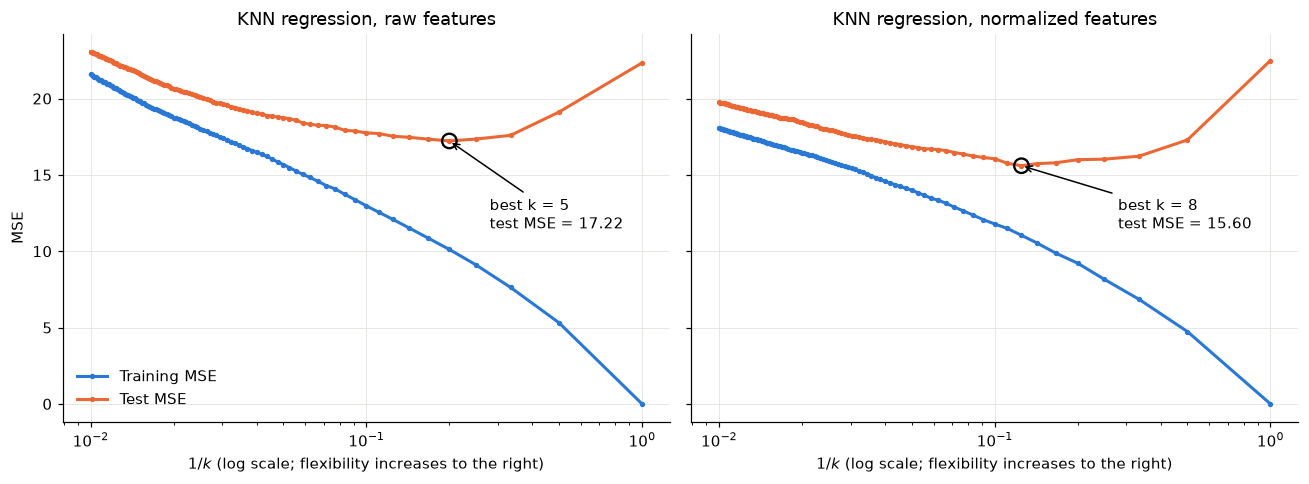

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name in zip(axes, ["raw", "normalized"]):
    res = knn_results[knn_results.features == name]
    best = best_knn.loc[name]
    ax.plot(1 / res.k, res["train MSE"], color=BLUE, marker="o", markersize=2.5, label="Training MSE")
    ax.plot(1 / res.k, res["test MSE"], color=ORANGE, marker="o", markersize=2.5, label="Test MSE")
    ax.scatter([1 / best.k], [best["test MSE"]], s=90, facecolors="none", edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(f"best k = {int(best.k)}\ntest MSE = {best['test MSE']:.2f}",
                xy=(1 / best.k, best["test MSE"]), xytext=(0.28, 11.5),
                arrowprops={"arrowstyle": "->", "color": "black"})
    ax.set_xscale("log")
    ax.set_xlabel("$1/k$ (log scale; flexibility increases to the right)")
    ax.set_title(f"KNN regression, {name} features")
axes[0].set_ylabel("MSE")
axes[0].legend(frameon=False, loc="lower left")
fig.tight_layout()
plt.show()

| Features | Best $k$ | Train MSE | Test MSE |
|---|---|---|---|
| raw | 5 | 10.12 | 17.22 |
| normalized (min–max) | 8 | 11.04 | 15.60 |

- Both curves show the usual bias–variance trade-off. The training MSE falls steadily to 0 as $1/k \to 1$. The test MSE is U-shaped: $k = 1$ overfits (test MSE about 22), while large $k$ oversmooths (at $k = 100$ the test MSE rises to about 23 for raw and 20 for normalized features).
- The best fit is **$k = 5$ with raw features** (test MSE 17.22) and **$k = 8$ with normalized features** (test MSE 15.60).
- **Normalization helps** (test MSE about 9% lower). The raw ranges are AT 35, V 56, AP 40, RH 75, so in raw Euclidean distance RH, the weakest predictor, counts the most and AT, the strongest, counts the least. After min–max scaling all four predictors weigh equally, and neighbours are chosen more by the variables that matter.
- Caveat: $k$ is chosen by the test error, as the question asks, so the reported best test MSE is slightly optimistic. A cleaner protocol would choose $k$ by cross-validation on the training set.

## 1(j) KNN vs. the best linear regression model

In [18]:
best_lin_name = results_h["test MSE"].idxmin()
comparison = pd.DataFrame({
    "train MSE": [results_h.loc[best_lin_name, "train MSE"]]
    + [best_knn.loc[n, "train MSE"] for n in ["raw", "normalized"]],
    "test MSE": [results_h.loc[best_lin_name, "test MSE"]]
    + [best_knn.loc[n, "test MSE"] for n in ["raw", "normalized"]],
}, index=[f"linear regression: {best_lin_name}"]
   + [f"KNN, {n} features (k = {int(best_knn.loc[n, 'k'])})" for n in ["raw", "normalized"]])
comparison

,train MSE,test MSE
linear regression: all interactions + squares (before selection),17.6979,19.0818
"KNN, raw features (k = 5)",10.1173,17.2225
"KNN, normalized features (k = 8)",11.0449,15.5992


The best linear regression model by test MSE is the 14-term model with all interactions and squares from 1(h). The selected 11-term model is equivalent (test MSE 19.083 vs. 19.082).

- **KNN wins on prediction accuracy.** KNN with normalized features ($k = 8$) reaches a test MSE of 15.60 against 19.08 for the best linear model, about 18% lower (test RMSE 3.95 vs. 4.37 MW). Even KNN on raw features (17.22) beats every linear model.
- **Why.** The true relationship is not exactly linear in the predictors, nor exactly quadratic with pairwise interactions (1(f) and 1(g) found cubic terms and several interactions). KNN makes no assumption about the form of $f$. With $n = 6697$ training points and only $p = 4$ predictors, there is enough data to estimate $f$ locally without suffering from the curse of dimensionality. This is exactly the setting of ISLR 2.4.1(a), where a flexible method is expected to do better.
- **Overfitting.** KNN has a larger gap between train and test error (11.0 vs. 15.6) than the linear model (17.7 vs. 19.1). It has higher variance, but its much lower bias more than makes up for it.
- **What linear regression keeps.** The linear model is interpretable: coefficients with p-values tell us, for example, that each $^\circ$C lowers output by about 2 MW. It predicts instantly, and it extrapolates in a controlled way. KNN is a black box, must store and search the whole training set, and cannot predict beyond the range of the training data.

If the goal is the most accurate prediction of hourly power output, KNN on normalized features is the better choice. If the goal is to understand how each ambient variable affects output, the linear model with interactions is more useful, at a modest cost in accuracy.

## 2. ISLR 2.4.1

*For each of parts (a)–(d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.*

### (a) The sample size $n$ is extremely large, and the number of predictors $p$ is small.

**Better.** With a huge sample and few predictors, a flexible method has enough data to estimate a complex $f$ without overfitting. Its variance stays small, and it gains from its lower bias.

### (b) The number of predictors $p$ is extremely large, and the number of observations $n$ is small.

**Worse.** With few observations and many predictors, a flexible method will fit the noise in the training data (overfitting), so its variance is very high. An inflexible method, such as linear regression with few parameters or a regularized one, has higher bias but much lower variance, and generally predicts better.

### (c) The relationship between the predictors and response is highly non-linear.

**Better.** An inflexible method like linear regression cannot represent a highly non-linear $f$, so it has large bias no matter how much data we have. A flexible method can adapt to the non-linear shape and reduce that bias.

### (d) The variance of the error terms, i.e. $\sigma^2 = \mathrm{Var}(\epsilon)$, is extremely high.

**Worse.** When the irreducible noise is very large, a flexible method will chase the noise and have high variance. An inflexible method averages the noise out better. Its extra bias costs little compared with the variance it saves.

## 3. ISLR 2.4.7

The training set has six observations, three predictors and a qualitative response:

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ |
|---|---|---|---|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | $-1$ | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

We want to predict $Y$ at the test point $X_1 = X_2 = X_3 = 0$ with K-nearest neighbors.

### (a) Euclidean distance between each observation and the test point

In [19]:
islr = pd.DataFrame(
    {"X1": [0, 2, 0, 0, -1, 1], "X2": [3, 0, 1, 1, 0, 1], "X3": [0, 0, 3, 2, 1, 1],
     "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]},
    index=pd.RangeIndex(1, 7, name="Obs."),
)
islr["distance"] = np.sqrt((islr[["X1", "X2", "X3"]] ** 2).sum(axis=1))
islr["rank"] = islr["distance"].rank().astype(int)
islr

,X1,X2,X3,Y,distance,rank
Obs.,,,,,,
1,0,3,0,Red,3.0000,5
2,2,0,0,Red,2.0000,3
3,0,1,3,Red,3.1623,6
4,0,1,2,Green,2.2361,4
5,-1,0,1,Green,1.4142,1
6,1,1,1,Red,1.7321,2


| Obs. | Distance | Value |
|---|---|---|
| 1 | $\sqrt{0^2 + 3^2 + 0^2} = \sqrt{9}$ | 3.000 |
| 2 | $\sqrt{2^2 + 0^2 + 0^2} = \sqrt{4}$ | 2.000 |
| 3 | $\sqrt{0^2 + 1^2 + 3^2} = \sqrt{10}$ | 3.162 |
| 4 | $\sqrt{0^2 + 1^2 + 2^2} = \sqrt{5}$ | 2.236 |
| 5 | $\sqrt{(-1)^2 + 0^2 + 1^2} = \sqrt{2}$ | 1.414 |
| 6 | $\sqrt{1^2 + 1^2 + 1^2} = \sqrt{3}$ | 1.732 |

### (b) Prediction with $K = 1$

**Green.** The single nearest neighbour is observation 5 (distance $\sqrt{2} \approx 1.41$), which is Green.

### (c) Prediction with $K = 3$

**Red.** The three nearest neighbours are observations 5 (Green, 1.41), 6 (Red, 1.73) and 2 (Red, 2.00). Two of the three are Red, so the estimated probability of Red is $2/3$ and the majority vote is Red.

### (d) Highly non-linear Bayes decision boundary

We would expect the best $K$ to be **small**. A small $K$ gives a flexible classifier whose decision boundary can bend to follow a highly non-linear Bayes boundary. As $K$ grows, the boundary averages over more and more points and becomes smoother, closer to linear, so it can no longer track the true boundary (high bias).